# PaluScope — Phase 0 — 02 Quality Analyzer

**Bloc C** de la feuille de route : contrôle de qualité des images (JusteAgbo05, branche `feature/phase0-quality-analyzer`).
Code réutilisable : `src/quality/` (`blur.py`, `exposure.py`, `contrast.py`, `color.py`, `analyzer.py`). Ce notebook explique, compare et calibre ; il ne contient pas la logique du module.

**Question :** comment mesurer simplement la netteté, l'exposition, le contraste et la couleur d'une image de frottis, et à partir de quelle valeur la signaler ?

**Contrainte de départ (notebook 01) :** aucune étiquette de qualité n'existe dans le dataset, et aucune image n'est saturée. On ne peut donc pas « mesurer une précision ».
La validation repose sur **trois outils** : (1) des dégradations synthétiques appliquées à de vraies images (floutage, éclaircissement, perte de contraste), (2) la comparaison visuelle des images signalées, (3) la relecture par l'équipe et le mentor.

| Section | Contenu |
|---|---|
| 1 | Configuration |
| 2 | Le contrat `analyze_image` sur trois images |
| 3 | Les mesures et leurs formules |
| 4 | Rapport sur toutes les images |
| 5 | Choix de la mesure de netteté (dégradation par flou) |
| 6 | Exposition et contraste (dégradations synthétiques) |
| 7 | Configuration retenue |
| 8 | Contrôle visuel des images signalées |
| 9 | Limites, journal des décisions |

## 1. Configuration

In [1]:
%load_ext autoreload
%autoreload 2

import json
import sys
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)

N_EVAL = 300                    # images utilisées pour les dégradations synthétiques (None = toutes ; plus lent)
SIGMAS = [0.5, 1.0, 1.5, 2.0, 3.0]   # intensités de flou testées (écart-type du filtre gaussien, en px)
FLAG_PCT = 5                    # un seuil « relatif » signale les FLAG_PCT % d'images les plus basses du dataset
SHARPNESS_METHOD = "laplacian"  # méthode retenue en section 5 : "laplacian", "tenengrad" ou "reblur"
CONTRAST_METHOD = "percentile"  # "percentile" ou "std"

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir() and (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.quality import analyze_image, blur, color, contrast, exposure
from src.quality.analyzer import DEFAULT_CONFIG, load_image

RAW_DIR, SAMPLES_DIR, PROCESSED_DIR = ROOT / "data" / "raw", ROOT / "data" / "samples", ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
jpg_dirs = Counter(p.parent for p in RAW_DIR.rglob("*") if p.suffix.lower() == ".jpg")
assert jpg_dirs, f"Aucune image .jpg sous {RAW_DIR} : voir data/README.md"
DATA_DIR = jpg_dirs.most_common(1)[0][0]
ALL_PATHS = sorted(DATA_DIR.glob("*.jpg"))
SAMPLE_PATHS = sorted(SAMPLES_DIR.glob("*.jpg")) or ALL_PATHS[:40]

print("Racine         :", ROOT)
print("Dataset        :", DATA_DIR.relative_to(ROOT), f"({len(ALL_PATHS)} images)")
print("data/samples   :", len(list(SAMPLES_DIR.glob('*.jpg'))), "images" + ("" if list(SAMPLES_DIR.glob('*.jpg')) else " (vide : les 40 premières images du dataset sont utilisées à la place)"))

Racine         : /home/juste-agbo/Bureau/PaluScope/PaluScope
Dataset        : data/raw/plasmodium_phonecamera (1182 images)
data/samples   : 40 images


## 2. Le contrat `analyze_image` sur trois images

`analyze_image(image, config=None)` accepte un tableau RGB `uint8` ou un chemin. Le retour suit `docs/conventions.md` (`sharpness`, `brightness`, `contrast`,
`overexposure_ratio`, `color_statistics`), avec deux ajouts à valider en équipe : `underexposure_ratio` (pixels quasi noirs, détecte les bords noirs) et `flags`
(un booléen par défaut détectable ; `None` signifie « seuil non calibré »).

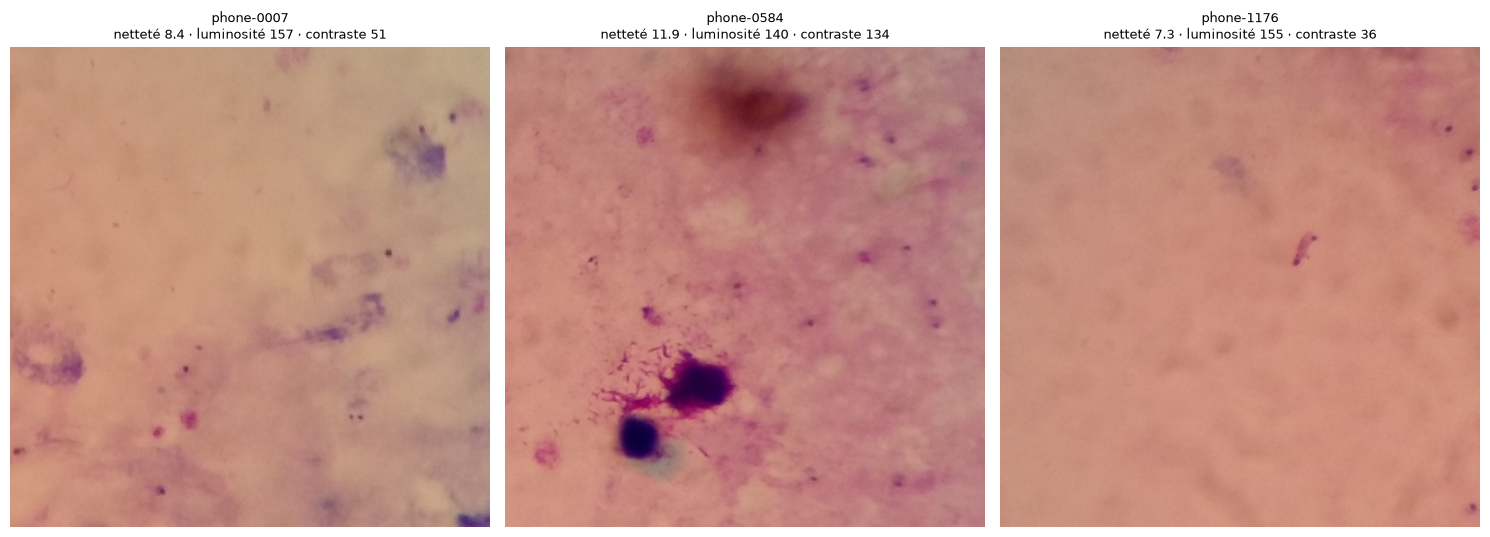

{
  "sharpness": 8.352200587121779,
  "brightness": 156.81110044444443,
  "contrast": 51.0,
  "overexposure_ratio": 0.0,
  "underexposure_ratio": 0.0,
  "color_statistics": {
    "mean_R": 191.68242844444444,
    "mean_G": 145.145664,
    "mean_B": 125.24531733333333,
    "std_R": 11.956207419690152,
    "std_G": 12.276692343134947,
    "std_B": 5.128323341488516,
    "ratio_R_G": 1.3206211137278232,
    "ratio_B_G": 0.862893963772375,
    "mean_H_circ": 8.864443997381255,
    "mean_S": 88.476512,
    "mean_V": 191.71001066666668
  },
  "flags": {
    "blurry": null,
    "low_contrast": null,
    "too_dark": false,
    "too_bright": false,
    "overexposed": false,
    "dark_borders": false
  }
}


In [2]:
pick = [SAMPLE_PATHS[i] for i in np.linspace(0, len(SAMPLE_PATHS) - 1, 3).astype(int)]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, p in zip(axes, pick):
    res = analyze_image(p)
    ax.imshow(load_image(p)); ax.axis("off")
    ax.set_title(f"{p.stem.replace('plasmodium-', '')}\nnetteté {res['sharpness']:.1f} · luminosité {res['brightness']:.0f} · contraste {res['contrast']:.0f}", fontsize=9)
plt.tight_layout(); plt.show()

print(json.dumps(analyze_image(pick[0]), indent=2, ensure_ascii=False))

## 3. Les mesures et leurs formules

Soit $G$ l'image en niveaux de gris, $G = 0{,}299\,R + 0{,}587\,V + 0{,}114\,B$, avec $N$ pixels $x_i \in [0, 255]$.

**Exposition**
- Luminosité : $\mu = \frac{1}{N}\sum_i x_i$.
- Surexposition : $\text{overexposure\_ratio} = \frac{1}{N}\,\#\{\,i : x_i \ge 250\,\}$ (part de pixels saturés). Sous-exposition : même formule avec $x_i \le 5$.

**Contraste**
- Écart-type : $\sigma = \sqrt{\frac{1}{N}\sum_i (x_i - \mu)^2}$.
- Étendue entre centiles : $p_{99} - p_{1}$, qui ignore quelques pixels extrêmes (retenue par défaut).

**Netteté** (un bord net produit de fortes variations locales ; un flou les lisse)
- Variance du Laplacien : $s_{\text{lap}} = \mathrm{Var}(\nabla^2 G)$, avec $\nabla^2 G = \partial^2_x G + \partial^2_y G$.
- Tenengrad : $s_{\text{ten}} = \frac{1}{N}\sum_i \left(G_x^2 + G_y^2\right)$, où $G_x, G_y$ sont les gradients de Sobel.
- Perte après re-flou : $s_{\text{reblur}} = 1 - \mathrm{Var}(\nabla^2(g_\sigma * G)) / \mathrm{Var}(\nabla^2 G)$ : proche de 1 si flouter détruit beaucoup de détails (image nette), proche de 0 si l'image était déjà floue.

**Couleur** : moyenne et écart-type de R, V, B ; moyenne de S et V ; **teinte moyenne circulaire**
$\bar h = \tfrac{1}{2}\,\mathrm{atan2}\!\left(\overline{\sin\theta},\overline{\cos\theta}\right)$ avec $\theta = H \cdot 2\pi/180$ (0 et 179 sont tous deux du rouge).

La netteté dépend de la résolution : `analyze_image` ramène donc le côté long à 750 px (`ref_size`) avant de la mesurer.

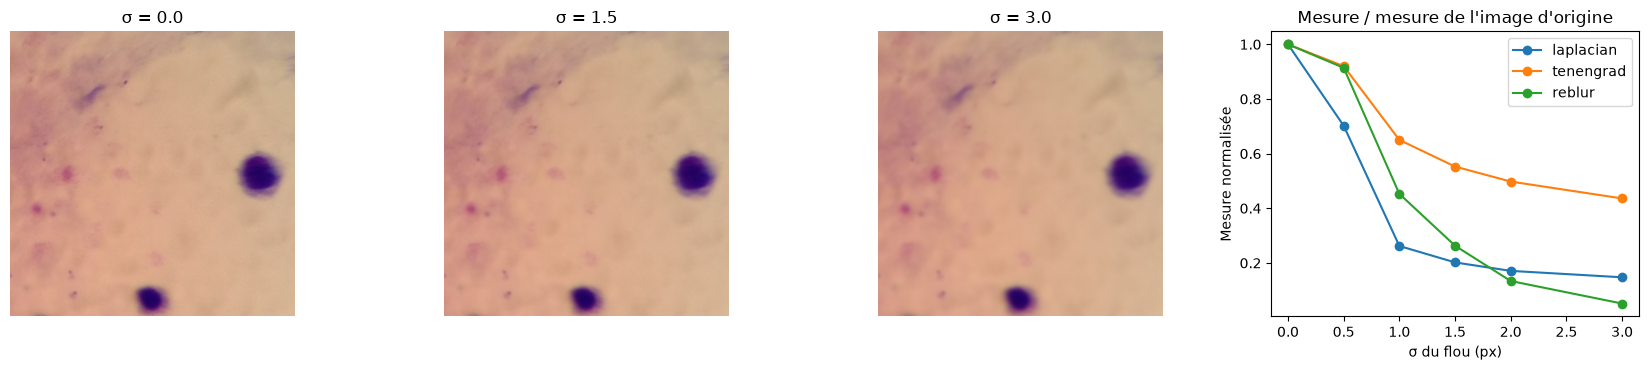

In [4]:
# Une image réelle, floutée progressivement : les trois mesures de netteté doivent décroître.
img = load_image(SAMPLE_PATHS[len(SAMPLE_PATHS) // 2])
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
levels = [0.0] + SIGMAS
vals = {m: [] for m in blur.METHODS}
for s in levels:
    g = gray if s == 0 else cv2.GaussianBlur(gray, (0, 0), s)
    for m in blur.METHODS:
        vals[m].append(blur.sharpness(g, m))

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, s in zip(ax[:3], (0.0, 1.5, 3.0)):
    a.imshow(img if s == 0 else cv2.GaussianBlur(img, (0, 0), s)); a.axis("off"); a.set_title(f"σ = {s}")
for m, v in vals.items():
    ax[3].plot(levels, np.array(v) / v[0], marker="o", label=m)
ax[3].set(title="Mesure / mesure de l'image d'origine", xlabel="σ du flou (px)", ylabel="Mesure normalisée"); ax[3].legend()
plt.tight_layout(); plt.show()

## 4. Rapport sur toutes les images

On calcule la sortie officielle `analyze_image` (config par défaut) et, pour la comparaison, les trois mesures de netteté et les deux mesures de contraste candidates.
`n_objects` (nombre de boîtes annotées) sert uniquement de **proxy du contenu** de l'image : il permet de voir si une mesure reflète la qualité ou la quantité de cellules.

In [5]:
def n_objects(path):
    xml = path.with_suffix(".xml")
    return xml.read_text(errors="ignore").count("<object>") if xml.exists() else np.nan

rows = []
for p in ALL_PATHS:
    res = analyze_image(p)
    gray = cv2.cvtColor(load_image(p), cv2.COLOR_RGB2GRAY)
    row = {"stem": p.stem, "n_objects": n_objects(p),
           "sharpness": res["sharpness"], "brightness": res["brightness"], "contrast": res["contrast"],
           "overexposure_ratio": res["overexposure_ratio"], "underexposure_ratio": res["underexposure_ratio"],
           **{f"sharp_{m}": blur.sharpness(gray, m) for m in blur.METHODS},
           **{f"contrast_{m}": contrast.contrast(gray, m) for m in contrast.METHODS},
           **res["color_statistics"]}
    rows.append(row)
df_q = pd.DataFrame(rows)
df_q.to_csv(PROCESSED_DIR / "phase0_quality_report.csv", index=False)   # data/processed n'est pas versionné
print(len(df_q), "images analysées")
display(df_q.drop(columns=["stem"]).describe().T.round(3))

1182 images analysées


,count,mean,std,min,25%,50%,75%,max
n_objects,1182.0,6.453,5.418,0.000,2.000,6.000,10.000,27.000
sharpness,1182.0,9.966,1.679,6.959,8.691,9.793,11.104,16.726
brightness,1182.0,146.989,7.560,120.592,141.832,147.638,152.376,169.702
contrast,1182.0,87.026,44.765,16.000,44.250,85.000,132.000,162.000
overexposure_ratio,1182.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
underexposure_ratio,1182.0,0.000,0.001,0.000,0.000,0.000,0.000,0.017
sharp_laplacian,1182.0,9.966,1.679,6.959,8.691,9.793,11.104,16.726
sharp_tenengrad,1182.0,169.717,73.077,54.965,114.262,166.819,213.627,540.536
sharp_reblur,1182.0,0.846,0.024,0.785,0.828,0.848,0.864,0.898
contrast_percentile,1182.0,87.026,44.765,16.000,44.250,85.000,132.000,162.000


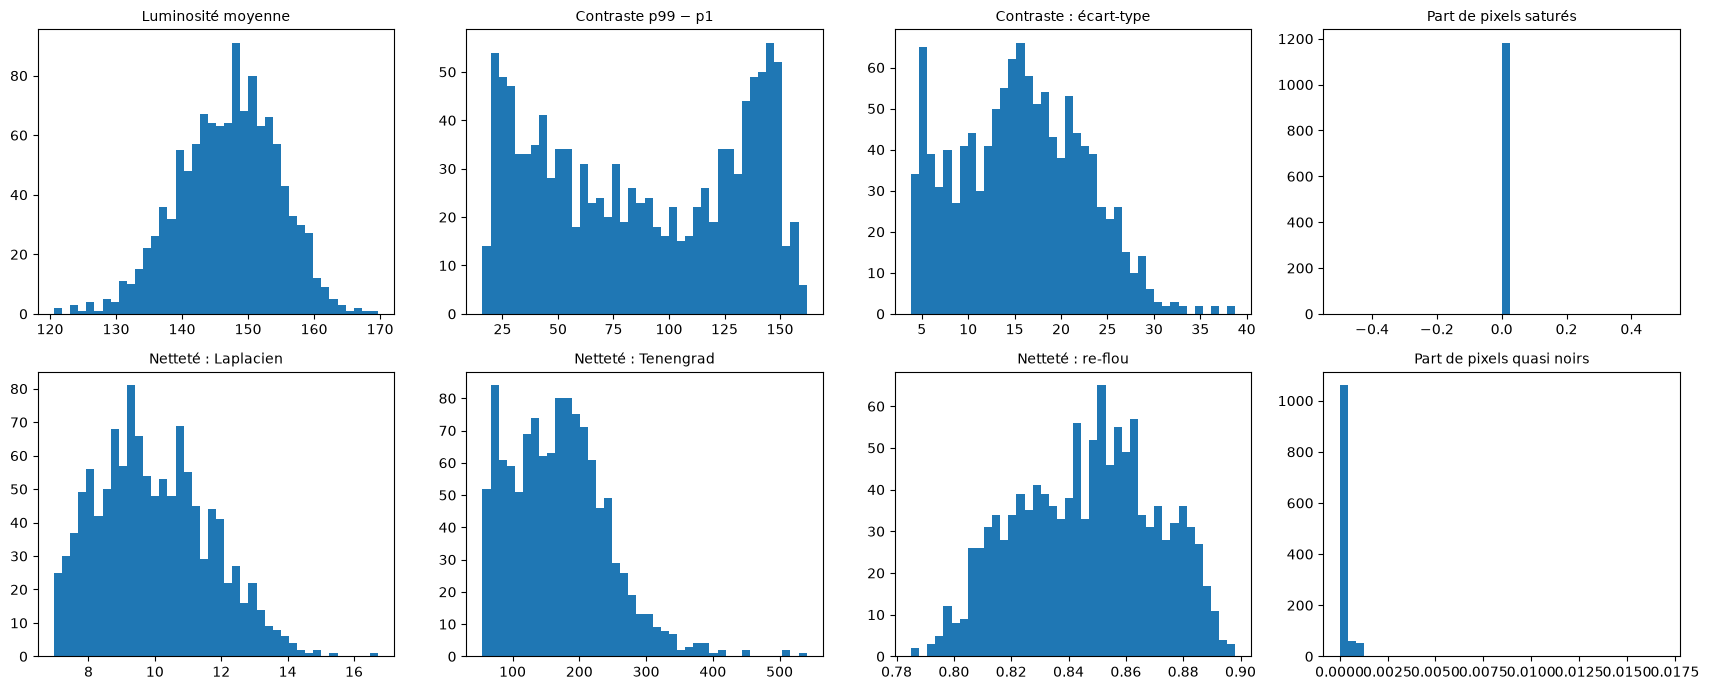

Images avec au moins un pixel saturé (≥ 250) : 0 sur 1182
Images avec plus de 0,5 % de pixels quasi noirs : 4


In [6]:
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
panels = [("brightness", "Luminosité moyenne"), ("contrast_percentile", "Contraste p99 − p1"), ("contrast_std", "Contraste : écart-type"),
          ("overexposure_ratio", "Part de pixels saturés"), ("sharp_laplacian", "Netteté : Laplacien"), ("sharp_tenengrad", "Netteté : Tenengrad"),
          ("sharp_reblur", "Netteté : re-flou"), ("underexposure_ratio", "Part de pixels quasi noirs")]
for a, (c, t) in zip(ax.ravel(), panels):
    a.hist(df_q[c], bins=40); a.set_title(t, fontsize=10)
plt.tight_layout(); plt.show()

print("Images avec au moins un pixel saturé (≥ 250) :", int((df_q.overexposure_ratio > 0).sum()), "sur", len(df_q))
print("Images avec plus de 0,5 % de pixels quasi noirs :", int((df_q.underexposure_ratio > DEFAULT_CONFIG["underexposure_max"]).sum()))

**Les mesures reflètent-elles la qualité ou le contenu ?** Corrélations de rang (Spearman) : si une mesure de netteté ou de contraste est fortement liée au nombre de cellules annotées
ou à la luminosité, elle dépend du contenu autant que de la qualité technique.

In [7]:
cols = ["sharp_laplacian", "sharp_tenengrad", "sharp_reblur", "contrast_percentile", "contrast_std", "brightness", "n_objects"]
display(df_q[cols].corr(method="spearman").round(2))

,sharp_laplacian,sharp_tenengrad,sharp_reblur,contrast_percentile,contrast_std,brightness,n_objects
sharp_laplacian,1.00,0.65,0.63,0.44,0.46,-0.74,0.31
sharp_tenengrad,0.65,1.00,-0.05,0.83,0.85,-0.51,0.56
sharp_reblur,0.63,-0.05,1.00,-0.10,-0.11,-0.31,-0.27
contrast_percentile,0.44,0.83,-0.10,1.00,0.97,-0.36,0.36
contrast_std,0.46,0.85,-0.11,0.97,1.00,-0.40,0.37
brightness,-0.74,-0.51,-0.31,-0.36,-0.40,1.00,-0.34
n_objects,0.31,0.56,-0.27,0.36,0.37,-0.34,1.00


## 5. Choix de la mesure de netteté

**Protocole.** Pour chaque mesure : (1) on prend un seuil qui signale les `FLAG_PCT` % d'images les plus basses du dataset d'origine ;
(2) on floute les mêmes images avec un σ croissant ; (3) on note la part des images floutées qui passent sous le seuil.
À taux de fausses alertes égal (`FLAG_PCT` %), la meilleure mesure détecte un flou **plus léger**.

**Limites.** Le dataset d'origine peut déjà contenir des images floues : les `FLAG_PCT` % ne sont pas des « fausses alertes » certaines, et les taux de détection sont une
comparaison **entre mesures**, pas une performance absolue. Un flou gaussien n'est qu'un modèle du flou réel (bougé, mise au point).

Part des images floutées signalées (seuil = centile 5 de 300 images d'origine) :


,σ=0.5,σ=1.0,σ=1.5,σ=2.0,σ=3.0
laplacian,93%,100%,100%,100%,100%
tenengrad,12%,31%,42%,49%,64%
reblur,89%,100%,100%,100%,100%


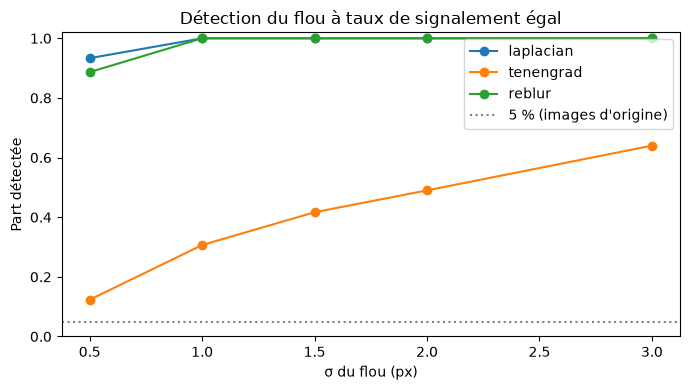

In [8]:
eval_paths = ALL_PATHS if N_EVAL is None else [ALL_PATHS[i] for i in sorted(rng.choice(len(ALL_PATHS), min(N_EVAL, len(ALL_PATHS)), replace=False))]
orig = {m: [] for m in blur.METHODS}
blurred = {m: {s: [] for s in SIGMAS} for m in blur.METHODS}
for p in eval_paths:                                   # une image à la fois (peu de mémoire)
    g = cv2.cvtColor(load_image(p), cv2.COLOR_RGB2GRAY)
    for m in blur.METHODS:
        orig[m].append(blur.sharpness(g, m))
    for s in SIGMAS:
        gb = cv2.GaussianBlur(g, (0, 0), s)
        for m in blur.METHODS:
            blurred[m][s].append(blur.sharpness(gb, m))
orig = {m: np.array(v) for m, v in orig.items()}
blurred = {m: {s: np.array(v) for s, v in d.items()} for m, d in blurred.items()}
thr_sharp = {m: float(np.percentile(orig[m], FLAG_PCT)) for m in blur.METHODS}

det = pd.DataFrame({m: {f"σ={s}": float((blurred[m][s] < thr_sharp[m]).mean()) for s in SIGMAS} for m in blur.METHODS}).T
print(f"Part des images floutées signalées (seuil = centile {FLAG_PCT} de {len(eval_paths)} images d'origine) :")
display(det.style.format("{:.0%}"))

fig, ax = plt.subplots(figsize=(7, 4))
for m in blur.METHODS:
    ax.plot(SIGMAS, det.loc[m].values, marker="o", label=m)
ax.axhline(FLAG_PCT / 100, color="gray", ls=":", label=f"{FLAG_PCT} % (images d'origine)")
ax.set(title="Détection du flou à taux de signalement égal", xlabel="σ du flou (px)", ylabel="Part détectée", ylim=(0, 1.02)); ax.legend()
plt.tight_layout(); plt.show()

## 6. Exposition et contraste : dégradations synthétiques

Comme aucune image n'est saturée, on **crée** des images surexposées, sous-exposées et à faible contraste pour vérifier que les mesures et les drapeaux réagissent comme attendu.
Éclaircir : $I' = \min(255,\, g \cdot I)$ avec $g > 1$ ; assombrir : $g < 1$ ; réduire le contraste : $I' = \mu + a\,(I - \mu)$ avec $0 < a < 1$.

In [9]:
def brighten(img, gain):  return np.clip(img.astype(np.float32) * gain, 0, 255).astype(np.uint8)
def lower_contrast(img, a):
    mu = img.mean()
    return np.clip(mu + a * (img.astype(np.float32) - mu), 0, 255).astype(np.uint8)

# seuil de contraste « relatif » : centile FLAG_PCT du dataset d'origine, pour la méthode retenue
contrast_col = f"contrast_{CONTRAST_METHOD}"
thr_contrast = float(np.percentile(df_q[contrast_col], FLAG_PCT))
CONFIG_EVAL = {"contrast_method": CONTRAST_METHOD, "contrast_min": thr_contrast}

expo_paths = eval_paths[:min(100, len(eval_paths))]
imgs = [load_image(p) for p in expo_paths]
cases = ([("original", lambda im: im)]
         + [(f"éclaircie ×{g}", (lambda im, g=g: brighten(im, g))) for g in (1.2, 1.4, 1.6, 2.0)]
         + [(f"assombrie ×{g}", (lambda im, g=g: brighten(im, g))) for g in (0.8, 0.6, 0.4)]
         + [(f"contraste ×{a}", (lambda im, a=a: lower_contrast(im, a))) for a in (0.7, 0.5, 0.3)])

rows = []
for name, fn in cases:
    res = [analyze_image(fn(im), CONFIG_EVAL) for im in imgs]
    rows.append({"dégradation": name,
                 "luminosité (méd.)": np.median([r["brightness"] for r in res]),
                 "pixels saturés (méd.)": np.median([r["overexposure_ratio"] for r in res]),
                 "contraste (méd.)": np.median([r["contrast"] for r in res]),
                 "% trop claire": 100 * np.mean([r["flags"]["too_bright"] for r in res]),
                 "% surexposée": 100 * np.mean([r["flags"]["overexposed"] for r in res]),
                 "% trop sombre": 100 * np.mean([r["flags"]["too_dark"] for r in res]),
                 "% contraste faible": 100 * np.mean([r["flags"]["low_contrast"] for r in res])})
df_deg = pd.DataFrame(rows).set_index("dégradation")
print(f"{len(imgs)} images, seuils provisoires : luminosité {DEFAULT_CONFIG['brightness_min']:.0f}–{DEFAULT_CONFIG['brightness_max']:.0f}, "
      f"saturation > {DEFAULT_CONFIG['overexposure_max']:.0%}, contraste < {thr_contrast:.1f}")
display(df_deg.round(3).style.format(precision=2))

100 images, seuils provisoires : luminosité 80–200, saturation > 5%, contraste < 23.0


,luminosité (méd.),pixels saturés (méd.),contraste (méd.),% trop claire,% surexposée,% trop sombre,% contraste faible
dégradation,,,,,,,
original,148.95,0.00,74.50,0.00,0.00,0.00,2.00
éclaircie ×1.2,178.33,0.00,88.50,0.00,0.00,0.00,0.00
éclaircie ×1.4,204.67,0.00,93.50,67.00,0.00,0.00,2.00
éclaircie ×1.6,225.34,0.00,94.50,100.00,25.00,0.00,0.00
éclaircie ×2.0,249.60,0.88,78.50,100.00,100.00,0.00,18.00
assombrie ×0.8,118.74,0.00,59.50,0.00,0.00,0.00,9.00
assombrie ×0.6,88.94,0.00,44.50,0.00,0.00,5.00,21.00
assombrie ×0.4,59.19,0.00,29.50,0.00,0.00,100.00,38.00
contraste ×0.7,148.42,0.00,52.50,0.00,0.00,0.00,14.00


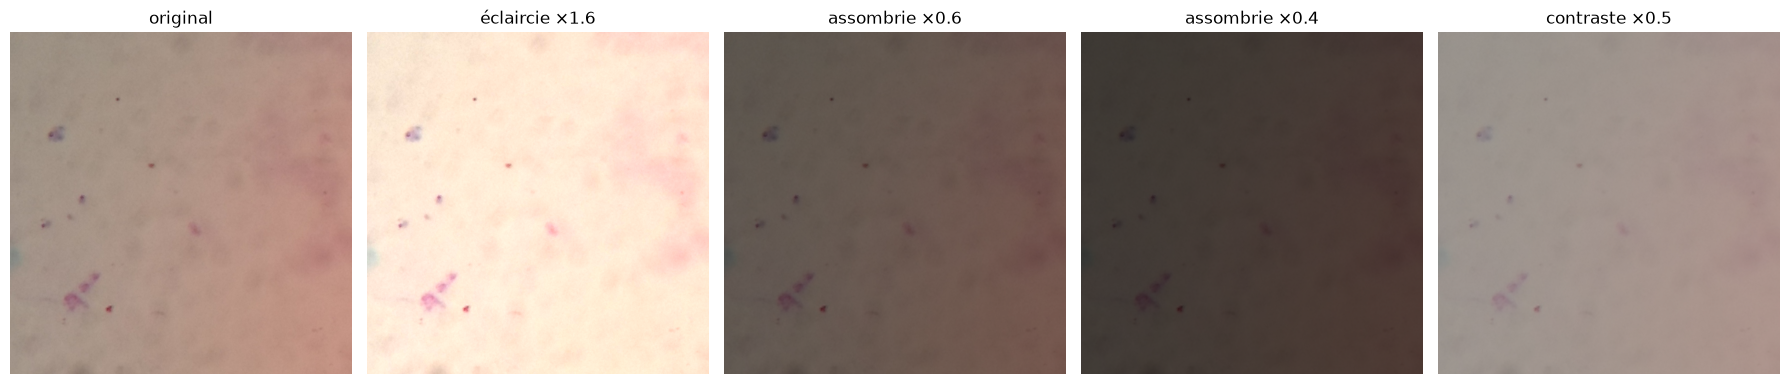

In [10]:
im0 = imgs[0]
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
for ax, (name, fn) in zip(axes, [cases[0], cases[3], cases[6], cases[7], cases[9]]):
    ax.imshow(fn(im0)); ax.axis("off"); ax.set_title(name)
plt.tight_layout(); plt.show()

## 7. Configuration retenue

In [11]:
CONFIG = {**DEFAULT_CONFIG,
          "sharpness_method": SHARPNESS_METHOD, "sharpness_min": thr_sharp[SHARPNESS_METHOD],
          "contrast_method": CONTRAST_METHOD, "contrast_min": thr_contrast}

print("À reporter dans DEFAULT_CONFIG (src/quality/analyzer.py) :")
for k in ("sharpness_method", "sharpness_min", "contrast_method", "contrast_min"):
    v = CONFIG[k]
    print(f'    "{k}": {v!r},' if not isinstance(v, float) else f'    "{k}": {v:.4g},')

# Vérification : analyze_image avec CONFIG donne les mêmes valeurs que le rapport de la section 4
idx = rng.choice(len(ALL_PATHS), 5, replace=False)
for i in idx:
    r = analyze_image(ALL_PATHS[i], CONFIG)
    assert np.isclose(r["sharpness"], df_q.loc[i, f"sharp_{SHARPNESS_METHOD}"]), "écart sur la netteté"
    assert np.isclose(r["contrast"], df_q.loc[i, f"contrast_{CONTRAST_METHOD}"]), "écart sur le contraste"
print("Cohérence rapport / analyze_image : OK sur", len(idx), "images")

À reporter dans DEFAULT_CONFIG (src/quality/analyzer.py) :
    "sharpness_method": 'laplacian',
    "sharpness_min": 7.381,
    "contrast_method": 'percentile',
    "contrast_min": 23,
Cohérence rapport / analyze_image : OK sur 5 images


## 8. Contrôle visuel des images signalées

Un seuil relatif signale toujours une part du dataset : ce qui compte est de **voir** si les images signalées sont bien celles qu'un lecteur jugerait moins bonnes.

flag_blurry          45
flag_low_contrast    50
flag_dark_borders     4
flag_too_dark         0
flag_too_bright       0
flag_overexposed      0
Images sans aucun drapeau : 1096 sur 1182


contraste faible,False,True
floue,,
False,1100,37
True,32,13


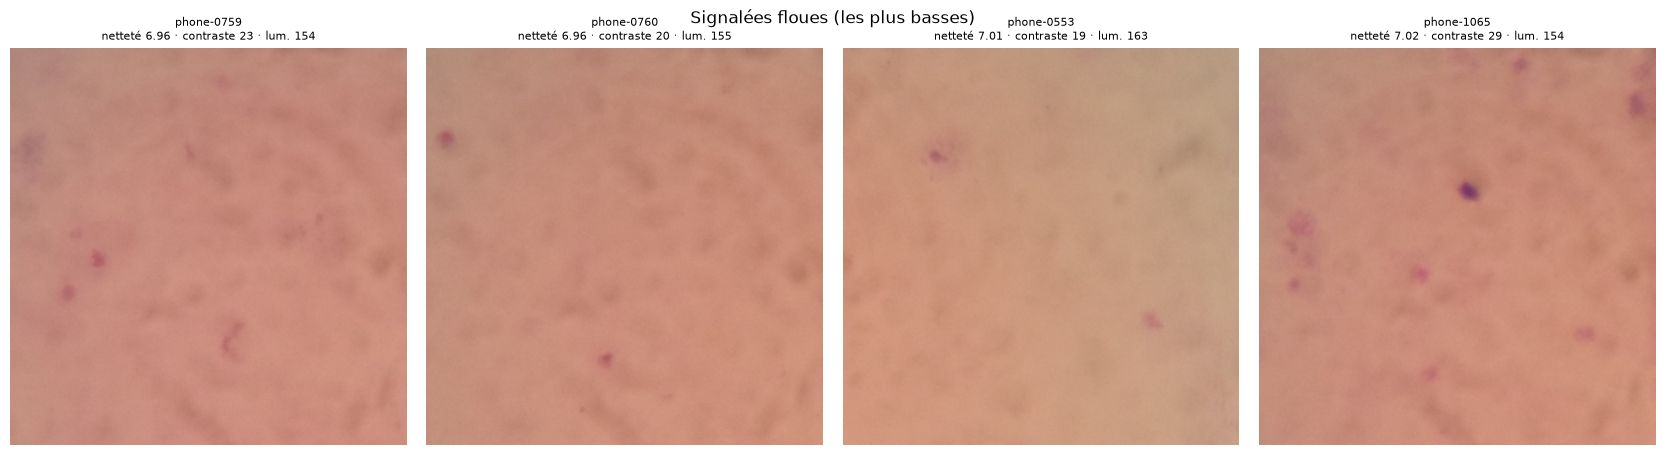

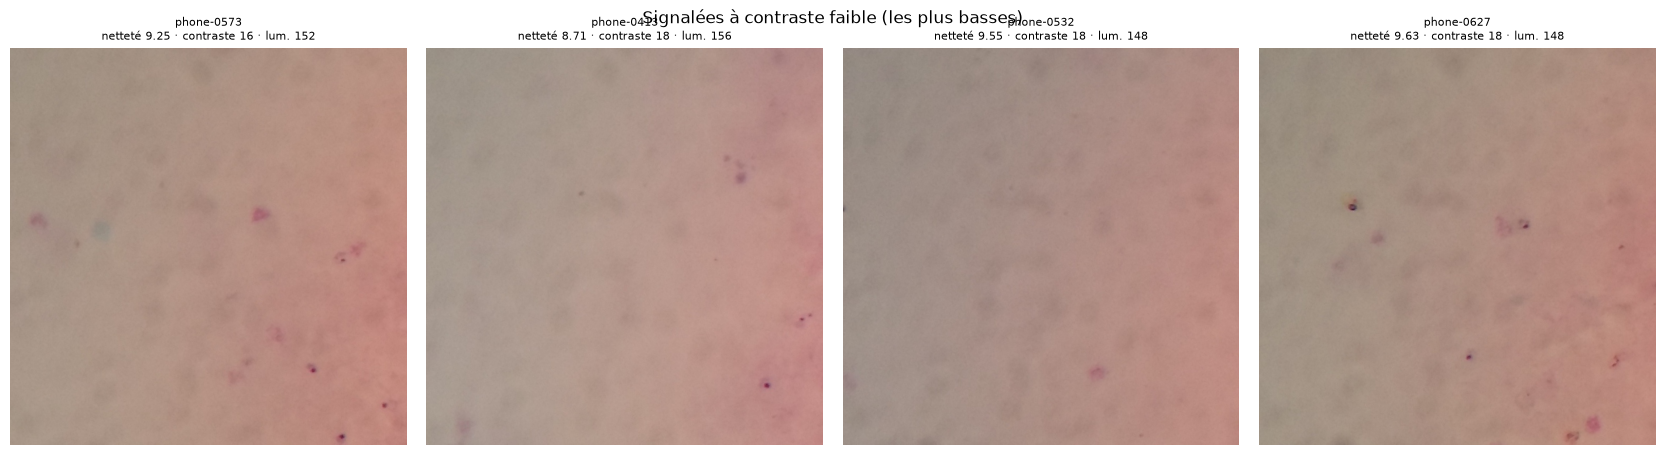

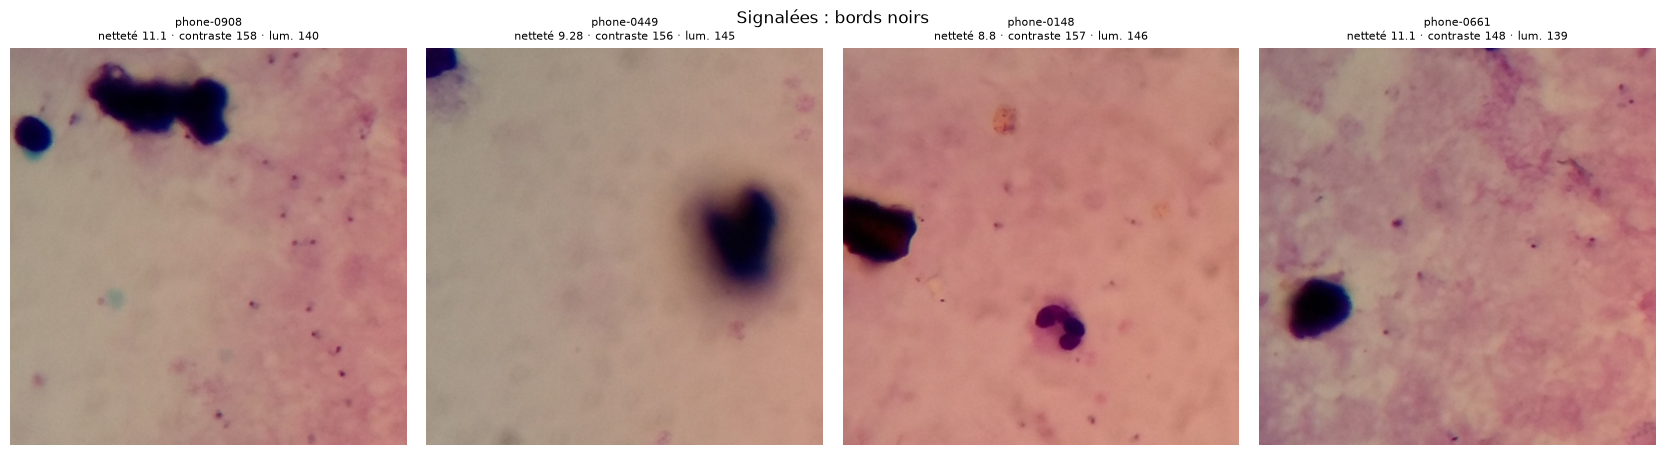

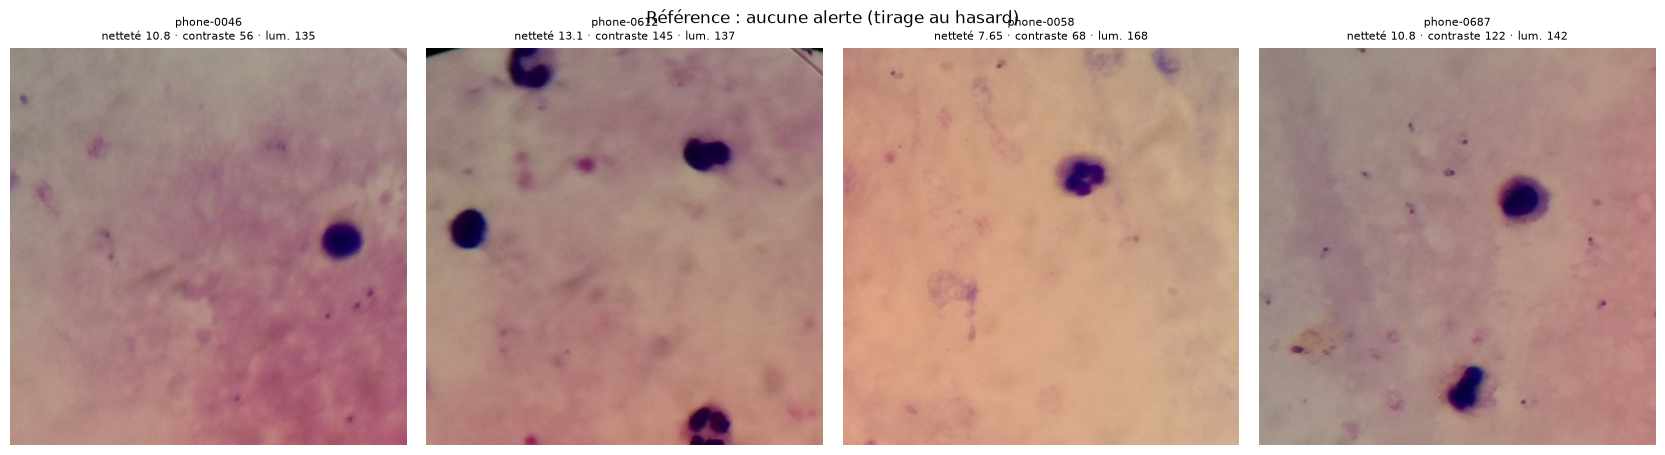

In [12]:
df_q["flag_blurry"] = df_q[f"sharp_{SHARPNESS_METHOD}"] < CONFIG["sharpness_min"]
df_q["flag_low_contrast"] = df_q[f"contrast_{CONTRAST_METHOD}"] < CONFIG["contrast_min"]
df_q["flag_dark_borders"] = df_q.underexposure_ratio > CONFIG["underexposure_max"]
df_q["flag_too_dark"] = df_q.brightness < CONFIG["brightness_min"]
df_q["flag_too_bright"] = df_q.brightness > CONFIG["brightness_max"]
df_q["flag_overexposed"] = df_q.overexposure_ratio > CONFIG["overexposure_max"]
flag_cols = [c for c in df_q if c.startswith("flag_")]
print(df_q[flag_cols].sum().to_string())
print("Images sans aucun drapeau :", int((~df_q[flag_cols].any(axis=1)).sum()), "sur", len(df_q))
display(pd.crosstab(df_q.flag_blurry, df_q.flag_low_contrast, rownames=["floue"], colnames=["contraste faible"]))
df_q.to_csv(PROCESSED_DIR / "phase0_quality_report.csv", index=False)

def gallery(stems, title, ncols=4):
    stems = list(stems)[:ncols]
    if not stems:
        print(title, ": aucune image"); return
    fig, axes = plt.subplots(1, len(stems), figsize=(4.2 * len(stems), 4.6)); axes = np.atleast_1d(axes)
    for ax, s in zip(axes, stems):
        r = df_q[df_q.stem == s].iloc[0]
        ax.imshow(load_image(DATA_DIR / f"{s}.jpg")); ax.axis("off")
        ax.set_title(f"{s.replace('plasmodium-', '')}\nnetteté {r[f'sharp_{SHARPNESS_METHOD}']:.3g} · contraste {r[contrast_col]:.0f} · lum. {r.brightness:.0f}", fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

gallery(df_q[df_q.flag_blurry].sort_values(f"sharp_{SHARPNESS_METHOD}").stem, "Signalées floues (les plus basses)")
gallery(df_q[df_q.flag_low_contrast].sort_values(contrast_col).stem, "Signalées à contraste faible (les plus basses)")
gallery(df_q[df_q.flag_dark_borders].sort_values("underexposure_ratio", ascending=False).stem, "Signalées : bords noirs")
gallery(df_q[~df_q[flag_cols].any(axis=1)].sample(4, random_state=SEED).stem, "Référence : aucune alerte (tirage au hasard)")

## 9. Limites, journal des décisions

**Limites connues**
- Aucune étiquette de qualité : les seuils de netteté et de contraste sont **relatifs** (centile du dataset) et les seuils d'exposition **provisoires**. Ils signalent « plus flou / moins contrasté que le reste de ce dataset », pas « inutilisable ».
- La netteté et le contraste dépendent du contenu : un champ pâle sans cellule a peu de bords et peut être signalé sans défaut réel (voir corrélations, section 4).
- Un flou gaussien synthétique ne représente ni le flou de bougé ni un mauvais focus.
- Un seul dataset (un type de coloration, un dispositif) : les seuils ne se transfèrent pas tels quels à un autre domaine, ce qui sera mesuré en Phase 3.

**À étudier plus tard**
- Contraste et netteté calculés sur le fond ou par zones, pour les séparer du contenu.
- Masque de vignette avant les mesures.
- Netteté locale (carte par tuiles), plus informative qu'un seul nombre.

**Lignes à reporter dans `docs/decisions.md`** (journal des décisions, à valider avec le mentor) :

In [13]:
print("| Date | Sujet | Décision et justification |")
print(f"| à compléter | Méthode de mesure du flou | {CONFIG['sharpness_method']}, seuil {CONFIG['sharpness_min']:.4g} (centile {FLAG_PCT} du dataset). "
      f"Comparée à tenengrad et reblur sur flou gaussien synthétique (σ de {SIGMAS[0]} à {SIGMAS[-1]} px), section 5. |")
print(f"| à compléter | Indicateur de contraste | {CONFIG['contrast_method']}, seuil {CONFIG['contrast_min']:.4g} (centile {FLAG_PCT} du dataset). |")
print(f"| à compléter | Détection de surexposition | part de pixels de gris ≥ {CONFIG['overexposure_thr']} > {CONFIG['overexposure_max']:.0%}, "
      f"et luminosité hors de [{CONFIG['brightness_min']:.0f}, {CONFIG['brightness_max']:.0f}]. Aucune saturation dans le dataset ({int((df_q.overexposure_ratio > 0).sum())} images concernées) : validée par éclaircissement synthétique, section 6. |")
print("| à compléter | Convention des sorties | cinq clés de docs/conventions.md + underexposure_ratio + flags (None = seuil non calibré). |")

| Date | Sujet | Décision et justification |
| à compléter | Méthode de mesure du flou | laplacian, seuil 7.381 (centile 5 du dataset). Comparée à tenengrad et reblur sur flou gaussien synthétique (σ de 0.5 à 3.0 px), section 5. |
| à compléter | Indicateur de contraste | percentile, seuil 23 (centile 5 du dataset). |
| à compléter | Détection de surexposition | part de pixels de gris ≥ 250 > 5%, et luminosité hors de [80, 200]. Aucune saturation dans le dataset (0 images concernées) : validée par éclaircissement synthétique, section 6. |
| à compléter | Convention des sorties | cinq clés de docs/conventions.md + underexposure_ratio + flags (None = seuil non calibré). |
